# Lecture 3: Denoising Diffusion Probabilistic Models (DDPMs)

<div class="nav-links">
  <a href="../../intro.html">About Me</a>
  <a href="../../publications.html">Publications</a>
  <a href="../../course_notes/my-teaching-philosophy.html">My Teaching</a>
  <a href="../../research_notes/intro.html">Research Notes</a>
</div>

---

In [15]:
# ============================================================
# Animation helpers (NumPy-only, proper controls preserved)
# Based on the working control pattern from your version
# ============================================================

import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ------------------------------------------------------------
# Plot range helper
# ------------------------------------------------------------
def compute_plot_limits(frames_a, frames_b=None, pad: float = 0.5):
    arrs = [np.concatenate(frames_a, axis=0)]
    if frames_b is not None:
        arrs.append(np.concatenate(frames_b, axis=0))
    all_pts = np.concatenate(arrs, axis=0)
    x_min, y_min = all_pts.min(axis=0)
    x_max, y_max = all_pts.max(axis=0)
    return (
        x_min - pad, x_max + pad,
        y_min - pad, y_max + pad
    )


# ------------------------------------------------------------
# Single animation
# ------------------------------------------------------------
def animate_single_trajectory(
    frames,
    title_prefix="Trajectory",
    interval=180,
    point_size=6,
    figsize=(5.4, 5.0)
):
    """
    frames: list of arrays [N, 2]
    Returns matplotlib animation object.
    """
    x_min, x_max, y_min, y_max = compute_plot_limits(frames)

    fig, ax = plt.subplots(figsize=figsize)

    scat = ax.scatter(
        frames[0][:, 0],
        frames[0][:, 1],
        s=point_size,
        alpha=0.80,
        linewidths=0
    )
    title = ax.set_title("", fontsize=12)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    ax.grid(True, alpha=0.25)

    fig.subplots_adjust(left=0.12, right=0.97, bottom=0.12, top=0.88)

    def init():
        scat.set_offsets(frames[0])
        title.set_text(f"{title_prefix} | frame 0/{len(frames)-1}")
        return scat, title

    def update(i):
        pts = frames[i]
        scat.set_offsets(pts)
        title.set_text(f"{title_prefix} | frame {i}/{len(frames)-1}")
        return scat, title

    ani = FuncAnimation(
        fig,
        update,
        frames=len(frames),
        init_func=init,
        interval=interval,
        blit=False,
        repeat=True
    )
    plt.close(fig)
    return ani


# ------------------------------------------------------------
# Side-by-side forward / reverse animation
# ------------------------------------------------------------
def animate_forward_and_reverse(
    forward_frames,
    reverse_frames,
    interval=180,
    point_size=6,
    figsize=(10.2, 4.8)
):
    """
    Side-by-side animation:
    left = forward noising trajectory
    right = reverse denoising trajectory

    Uses plain Matplotlib JS HTML output so controls stay correct.
    """
    n_frames = min(len(forward_frames), len(reverse_frames))
    forward_frames = forward_frames[:n_frames]
    reverse_frames = reverse_frames[:n_frames]

    x_min, x_max, y_min, y_max = compute_plot_limits(forward_frames, reverse_frames)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax_fwd, ax_rev = axes

    scat_fwd = ax_fwd.scatter(
        forward_frames[0][:, 0],
        forward_frames[0][:, 1],
        s=point_size,
        alpha=0.80,
        linewidths=0
    )
    scat_rev = ax_rev.scatter(
        reverse_frames[0][:, 0],
        reverse_frames[0][:, 1],
        s=point_size,
        alpha=0.80,
        linewidths=0
    )

    title_fwd = ax_fwd.set_title("", fontsize=12)
    title_rev = ax_rev.set_title("", fontsize=12)

    for ax in axes:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.axis("equal")
        ax.grid(True, alpha=0.25)

    fig.subplots_adjust(
        left=0.07,
        right=0.985,
        bottom=0.13,
        top=0.86,
        wspace=0.16
    )

    def init():
        scat_fwd.set_offsets(forward_frames[0])
        scat_rev.set_offsets(reverse_frames[0])
        title_fwd.set_text("Forward diffusion")
        title_rev.set_text("Reverse diffusion")
        return scat_fwd, scat_rev, title_fwd, title_rev

    def update(i):
        scat_fwd.set_offsets(forward_frames[i])
        scat_rev.set_offsets(reverse_frames[i])

        title_fwd.set_text(f"Forward diffusion | frame {i}/{n_frames-1}")
        title_rev.set_text(f"Reverse diffusion | frame {i}/{n_frames-1}")
        return scat_fwd, scat_rev, title_fwd, title_rev

    ani = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        init_func=init,
        interval=interval,
        blit=False,
        repeat=True
    )
    plt.close(fig)
    return ani


# ------------------------------------------------------------
# Display helper
# Keeps controls intact
# ------------------------------------------------------------
def show_animation(ani):
    """
    Plain Matplotlib JSHTML display so controls remain correct.
    Also suppresses noisy animation warnings.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        html = ani.to_jshtml()
    display(HTML(html))


# ============================================================
# Build and display animations (NumPy-only)
# Assumes these already exist:
# - x_np
# - schedule
# - model
# - sample_forward_trajectory
# - sample_reverse_trajectory
# ============================================================

n_anim = 1600   # reduced slightly so it fits and stays responsive
x0_anim = x_np[:n_anim].astype(np.float64)

forward_frames = sample_forward_trajectory(
    x0_anim,
    schedule,
    store_every=8
)

reverse_frames = sample_reverse_trajectory(
    model=model,
    n_samples=n_anim,
    schedule=schedule,
    store_every=8
)

ani_both = animate_forward_and_reverse(
    forward_frames=forward_frames,
    reverse_frames=reverse_frames,
    interval=220,
    point_size=5,
    figsize=(10.2, 4.8)
)

show_animation(ani_both)

This notebook is a mathematically rigorous, structured tutorial on **Denoising Diffusion Probabilistic Models (DDPMs)**.

Goals of this notebook:

1. Build all prerequisites needed for DDPMs.
2. Derive the DDPM forward process and reverse process carefully.
3. Derive the variational objective and the practical training objective.
4. Connect the theory to implementation and visualization.
5. Provide plots and toy demonstrations for intuition.

We will use the following notation throughout:

- $x_0$: clean data sample
- $x_t$: latent/noisy sample at diffusion step $t$
- $q(\cdot)$: fixed forward/noising distributions
- $p_\theta(\cdot)$: learned reverse/generative distributions
- $\beta_t$: forward variance schedule
- $\alpha_t := 1 - \beta_t$
- $\bar{\alpha}_t := \prod_{s=1}^t \alpha_s$, with $\bar{\alpha}_0 = 1$

We assume data lives in $\mathbb{R}^d$.

## Notebook roadmap

This notebook is organized as follows:

1. Prerequisites
2. Diffusion intuition
3. Forward process derivation
4. Closed form for $q(x_t \mid x_0)$
5. Posterior $q(x_{t-1} \mid x_t, x_0)$
6. Reverse process model
7. ELBO derivation
8. Practical DDPM loss
9. $\epsilon$-prediction, $x_0$-prediction, and $v$-prediction
10. Training algorithm
11. Sampling algorithm
12. Implementation notes
13. Common confusions
14. Summary

Throughout, markdown cells contain the theory and derivations, while code cells are used for helper utilities and visual demonstrations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

## Prerequisites

Before deriving DDPMs, we need a strong grasp of:

- probability densities and conditional distributions
- Gaussian and multivariate Gaussian distributions
- expectation and variance
- KL divergence
- change of variables
- Markov chains
- latent variable models
- variational inference and ELBO
- score function intuition
- Gaussian identities
- reparameterization-style identities

We now go through these carefully.



### 1. Probability densities and conditional distributions

Let $x \in \mathbb{R}^d$ be a continuous random variable with density $p(x)$. Then

$$
p(x) \ge 0, \qquad \int p(x)\,dx = 1.
$$

For two random variables $x$ and $y$, the **joint density** is $p(x,y)$, and the **conditional density** is

$$
p(x \mid y) = \frac{p(x,y)}{p(y)},
$$

whenever $p(y) > 0$, where

$$
p(y) = \int p(x,y)\,dx.
$$

The product rule gives

$$
p(x,y) = p(x \mid y)p(y) = p(y \mid x)p(x).
$$

For a sequence $x_{0:T} := (x_0, x_1, \dots, x_T)$,

$$
p(x_{0:T}) = p(x_0)\prod_{t=1}^T p(x_t \mid x_{0:t-1}).
$$

A Markov chain is the special case where

$$
p(x_t \mid x_{0:t-1}) = p(x_t \mid x_{t-1}).
$$

Then

$$
p(x_{0:T}) = p(x_0)\prod_{t=1}^T p(x_t \mid x_{t-1}).
$$

This is exactly the structure used in diffusion models.

### 2. Gaussian distributions

#### 2.1 Univariate Gaussian

A scalar Gaussian with mean $\mu$ and variance $\sigma^2$ is

$$
\mathcal{N}(x; \mu, \sigma^2)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right).
$$

#### 2.2 Multivariate Gaussian

In $\mathbb{R}^d$, a Gaussian with mean $\mu \in \mathbb{R}^d$ and covariance $\Sigma \in \mathbb{R}^{d \times d}$ is

$$
\mathcal{N}(x; \mu, \Sigma)
=
\frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}}
\exp\left(
-\frac{1}{2}(x-\mu)^\top \Sigma^{-1}(x-\mu)
\right).
$$

In DDPMs, we frequently use isotropic covariances such as $\sigma^2 I$.

### 3. Expectation and variance

For a density $p(x)$, the expectation of a function $f(x)$ is

$$
\mathbb{E}_{p(x)}[f(x)] = \int f(x)p(x)\,dx.
$$

The mean is

$$
\mu = \mathbb{E}[x].
$$

The covariance is

$$
\mathrm{Cov}(x) = \mathbb{E}\left[(x-\mu)(x-\mu)^\top\right].
$$

For a scalar variable, variance is

$$
\mathrm{Var}(x) = \mathbb{E}[(x-\mu)^2].
$$

Useful identity:

$$
\mathrm{Var}(x) = \mathbb{E}[x^2] - \mathbb{E}[x]^2.
$$

Linearity of expectation:

$$
\mathbb{E}[ax + by] = a\mathbb{E}[x] + b\mathbb{E}[y].
$$

These become important when we manipulate Gaussian noise processes in diffusion.

### 4. KL divergence

For two densities $q(x)$ and $p(x)$, the KL divergence is

$$
D_{\mathrm{KL}}(q \| p)
=
\int q(x)\log \frac{q(x)}{p(x)}\,dx
=
\mathbb{E}_{q(x)}\left[\log \frac{q(x)}{p(x)}\right].
$$

Important facts:

- $D_{\mathrm{KL}}(q \| p) \ge 0$
- $D_{\mathrm{KL}}(q \| p) = 0$ iff $q=p$ almost everywhere
- it is not symmetric

For Gaussians,

$$
q = \mathcal{N}(\mu_q, \Sigma_q), \qquad p = \mathcal{N}(\mu_p, \Sigma_p),
$$

the KL divergence is

$$
D_{\mathrm{KL}}(q\|p)
=
\frac{1}{2}
\left[
\log\frac{|\Sigma_p|}{|\Sigma_q|}
- d
+ \mathrm{tr}(\Sigma_p^{-1}\Sigma_q)
+ (\mu_p-\mu_q)^\top \Sigma_p^{-1}(\mu_p-\mu_q)
\right].
$$

This is crucial in DDPMs because the ELBO decomposes into KL terms between Gaussian distributions.

### 5. Change of variables

If $z = f(x)$ is invertible and differentiable, then

$$
p_Z(z) = p_X(f^{-1}(z))
\left|
\det \frac{\partial f^{-1}(z)}{\partial z}
\right|.
$$

Equivalently,

$$
p_X(x) = p_Z(f(x))
\left|
\det \frac{\partial f(x)}{\partial x}
\right|.
$$

Diffusion models are not usually presented as normalizing flows, but the mindset that densities transform under mappings is still useful, especially when thinking about how noisy variables relate to clean variables.

### 6. Markov chains

A sequence $x_0, x_1, \dots, x_T$ is a Markov chain if

$$
q(x_t \mid x_{0:t-1}) = q(x_t \mid x_{t-1}).
$$

Then

$$
q(x_{0:T}) = q(x_0)\prod_{t=1}^T q(x_t \mid x_{t-1}).
$$

Diffusion models use two Markov chains:

- a forward chain $q(x_{1:T} \mid x_0)$ that gradually adds noise
- a reverse chain $p_\theta(x_{0:T})$ that gradually removes noise

### 7. Latent variable models

A latent variable model introduces hidden variables $z$:

$$
p_\theta(x,z) = p(z)p_\theta(x \mid z).
$$

The marginal likelihood is

$$
p_\theta(x) = \int p_\theta(x,z)\,dz.
$$

This integral is often intractable.

Diffusion models can be viewed as a latent variable model with many latent variables:

$$
x_1, x_2, \dots, x_T.
$$

Here, $x_0$ is observed data and the intermediate noisy states are latent variables.

### 8. Variational inference and ELBO

Suppose we want to maximize $\log p_\theta(x)$, but marginalization over latent variables is hard. Introduce an approximate posterior $q(z \mid x)$:

$$
\log p_\theta(x)
=
\log \int q(z \mid x)\frac{p_\theta(x,z)}{q(z \mid x)}\,dz.
$$

Applying Jensen's inequality,

$$
\log p_\theta(x)
\ge
\mathbb{E}_{q(z \mid x)}
\left[
\log p_\theta(x,z) - \log q(z \mid x)
\right].
$$

This lower bound is the ELBO:

$$
\mathrm{ELBO}
=
\mathbb{E}_{q(z \mid x)}
\left[
\log p_\theta(x,z) - \log q(z \mid x)
\right].
$$

Also,

$$
\log p_\theta(x)
=
\mathrm{ELBO}
+
D_{\mathrm{KL}}(q(z \mid x)\|p_\theta(z \mid x)).
$$

In DDPMs, the latent variables are $x_{1:T}$ and the forward diffusion process $q(x_{1:T}\mid x_0)$ plays the role of the variational distribution.

### 9. Score function intuition

The **score** of a density $p(x)$ is

$$
\nabla_x \log p(x).
$$

It tells us the direction in which the density increases most rapidly.

In diffusion, denoising is closely related to learning the score of noisy data distributions. Later we will see that predicting the added noise $\epsilon$ is closely tied to predicting the score.

### 10. Why Gaussian identities matter

DDPM derivations rely on the following Gaussian facts:

1. Linear combinations of Gaussians are Gaussian.
2. Adding Gaussian noise to a Gaussian yields another Gaussian.
3. Products of Gaussian densities are proportional to Gaussians.
4. Conditionals of jointly Gaussian variables are Gaussian.

These facts are what make the following quantities analytically tractable:

- $q(x_t \mid x_0)$
- $q(x_{t-1} \mid x_t, x_0)$
- the KL terms in the ELBO

### 11. Reparameterization-style identities

If $\epsilon \sim \mathcal{N}(0,I)$, then

$$
x = \mu + \sigma \epsilon
$$

has distribution

$$
x \sim \mathcal{N}(\mu, \sigma^2 I).
$$

More generally, if $LL^\top = \Sigma$, then

$$
x = \mu + L\epsilon, \qquad \epsilon \sim \mathcal{N}(0,I)
$$

implies

$$
x \sim \mathcal{N}(\mu, \Sigma).
$$

This is the style of identity we repeatedly use in diffusion when writing noisy variables as clean signal plus scaled Gaussian noise.

## Diffusion intuition

We now step back and understand the big picture before doing the full derivation.

### What problem diffusion models solve

We want to model a complicated data distribution $p_{\text{data}}(x)$ and generate new samples from it.

Direct generation in one shot is hard because the data distribution is high-dimensional and highly structured.

Diffusion models solve this by breaking the problem into many small denoising steps:

1. Define a simple process that gradually corrupts data into Gaussian noise.
2. Learn to reverse that process one small step at a time.

This turns a hard generation problem into a sequence of easier local denoising problems.

### How diffusion differs from VAEs and GANs

#### VAEs
VAEs are latent variable models trained via an ELBO. They are principled and likelihood-based, but often produce blurrier samples.

#### GANs
GANs can generate sharp samples but training can be unstable and they do not directly optimize likelihood.

#### DDPMs
DDPMs are likelihood-based latent-variable generative models trained using a denoising objective closely tied to a variational bound. They are stable to train and generate high-quality samples by iterative refinement.

### Forward diffusion vs reverse diffusion

The **forward diffusion process** gradually adds noise:

$$
x_0 \to x_1 \to x_2 \to \cdots \to x_T.
$$

By the end, $x_T$ is approximately standard Gaussian noise.

The **reverse diffusion process** learns to invert this corruption:

$$
x_T \to x_{T-1} \to \cdots \to x_1 \to x_0.
$$

At generation time, we start from Gaussian noise and repeatedly denoise.

In [2]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    return np.linspace(beta_start, beta_end, T, dtype=np.float64)

def cosine_alpha_bar_schedule(T, s=0.008):
    steps = np.arange(T + 1, dtype=np.float64)
    f = np.cos(((steps / T) + s) / (1 + s) * np.pi / 2) ** 2
    alpha_bar = f / f[0]
    betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
    return np.clip(betas, 1e-8, 0.999)

def compute_diffusion_quantities(betas):
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas)
    alpha_bars_prev = np.concatenate([[1.0], alpha_bars[:-1]])
    posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)
    return {
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
        "alpha_bars_prev": alpha_bars_prev,
        "posterior_variance": posterior_variance
    }

The next plot shows the role of the noise schedule. This is one of the most important practical ingredients in diffusion.

We will visualize:

- $\beta_t$: the noise added at each step
- $\alpha_t = 1 - \beta_t$: the signal retention at each step
- $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$: the cumulative signal retention

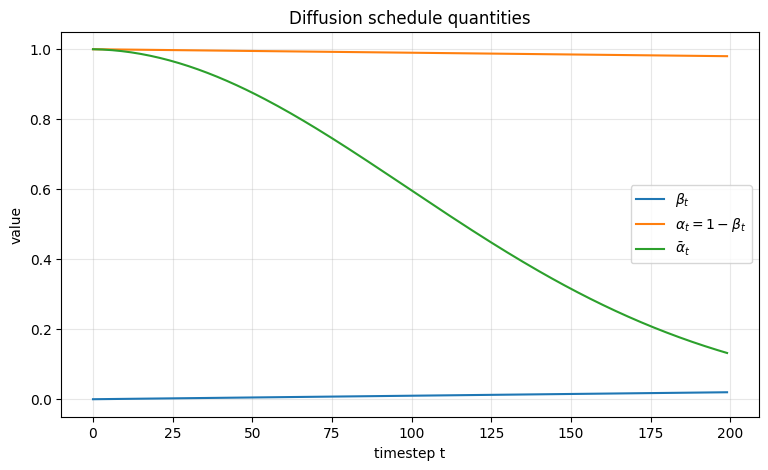

In [3]:
T = 200
betas = linear_beta_schedule(T)
q = compute_diffusion_quantities(betas)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(q["betas"], label=r'$\beta_t$')
ax.plot(q["alphas"], label=r'$\alpha_t = 1-\beta_t$')
ax.plot(q["alpha_bars"], label=r'$\bar{\alpha}_t$')
ax.set_title("Diffusion schedule quantities")
ax.set_xlabel("timestep t")
ax.set_ylabel("value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

#### Interpretation of the plot

- $\beta_t$ determines how much fresh noise is injected at each step.
- $\alpha_t$ determines how much of the previous signal survives each step.
- $\bar{\alpha}_t$ tells us how much of the original signal $x_0$ survives after $t$ steps.

Later we will show that

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I),
$$

so $\bar{\alpha}_t$ is the central cumulative quantity in DDPMs.

## Forward process derivation

We now derive the forward diffusion process carefully.

### Definition of the forward process

Choose a variance schedule $\{\beta_t\}_{t=1}^T$ with $\beta_t \in (0,1)$ and define

$$
\alpha_t := 1 - \beta_t.
$$

The forward process is defined by

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}\left(x_t; \sqrt{\alpha_t}x_{t-1}, \beta_t I\right).
$$

Equivalently,

$$
x_t = \sqrt{\alpha_t}x_{t-1} + \sqrt{\beta_t}\epsilon_t,
\qquad \epsilon_t \sim \mathcal{N}(0,I).
$$

So each step:

1. shrinks the previous signal by $\sqrt{\alpha_t}$
2. adds fresh Gaussian noise of variance $\beta_t I$

### Why this parameterization is useful

The parameterization

$$
x_t = \sqrt{\alpha_t}x_{t-1} + \sqrt{\beta_t}\epsilon_t
$$

is convenient because:

- it keeps the process Gaussian
- it separates signal retention and noise injection
- it gives clean cumulative formulas in terms of $\bar{\alpha}_t$

The full forward chain factorizes as

$$
q(x_{1:T} \mid x_0)
=
\prod_{t=1}^T q(x_t \mid x_{t-1}).
$$


In [5]:
def sample_forward_iterative(x0, betas, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = np.array(x0, dtype=np.float64)
    xs = [x.copy()]
    for beta in betas:
        alpha = 1.0 - beta
        noise = rng.normal(size=x.shape)
        x = np.sqrt(alpha) * x + np.sqrt(beta) * noise
        xs.append(x.copy())
    return np.array(xs)

def sample_xt_closed_form(x0, t, alpha_bars, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    noise = rng.normal(size=np.array(x0).shape)
    return np.sqrt(alpha_bars[t - 1]) * x0 + np.sqrt(1.0 - alpha_bars[t - 1]) * noise, noise

The next demonstration visualizes the forward noising process on a simple 1D signal. This is not meant to be a realistic image diffusion example; it is purely pedagogical so we can see how the signal is gradually destroyed by noise.

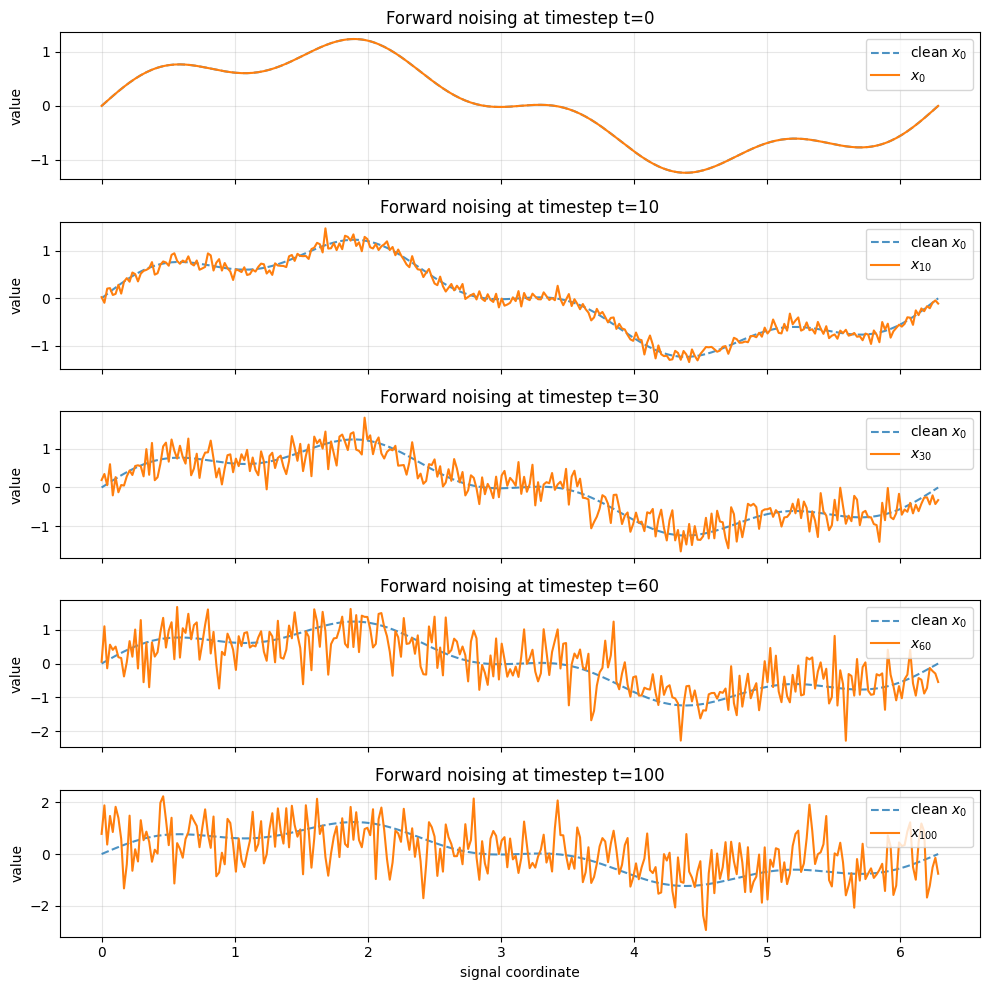

In [8]:
# Better visualization of forward noising:
# 1) separate subplots for selected timesteps
# 2) heatmap of the whole trajectory over time
# 3) signal/noise coefficients across timesteps

import numpy as np
import matplotlib.pyplot as plt

# --- simple clean 1D signal ---
n = 300
x_axis = np.linspace(0, 2 * np.pi, n)
x0_signal = np.sin(x_axis) + 0.3 * np.sin(4 * x_axis)

# --- diffusion schedule ---
T_demo = 100
betas_demo = linear_beta_schedule(T_demo, 1e-4, 2e-2)
sched_demo = compute_diffusion_quantities(betas_demo)

# --- generate one forward trajectory iteratively ---
rng = np.random.default_rng(42)
xs_demo = sample_forward_iterative(x0_signal, betas_demo, rng=rng)   # shape: [T+1, n]

# ---------------------------------------------------
# Figure 1: separate subplots for selected timesteps
# ---------------------------------------------------
timesteps_to_show = [0, 10, 30, 60, 100]

fig, axes = plt.subplots(len(timesteps_to_show), 1, figsize=(10, 10), sharex=True)

for ax, t in zip(axes, timesteps_to_show):
    ax.plot(x_axis, x0_signal, linestyle='--', alpha=0.8, label=r'clean $x_0$')
    ax.plot(x_axis, xs_demo[t], label=fr'$x_{{{t}}}$')
    ax.set_ylabel("value")
    ax.set_title(f"Forward noising at timestep t={t}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("signal coordinate")
plt.tight_layout()
plt.show()

#### Interpretation

At early timesteps, the signal still strongly resembles $x_0$.

At later timesteps, signal structure is weakened and noise dominates.

This is exactly what the diffusion forward process is designed to do: transform complicated data into something close to standard Gaussian noise.

## Closed form for $q(x_t \mid x_0)$

This is one of the central derivations in DDPMs.

We will derive

$$
q(x_t \mid x_0)
=
\mathcal{N}\left(
x_t;
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right),
$$

where

$$
\bar{\alpha}_t := \prod_{s=1}^t \alpha_s.
$$

### Step-by-step derivation of $q(x_t \mid x_0)$

From the one-step forward process,

$$
x_t = \sqrt{\alpha_t}x_{t-1} + \sqrt{\beta_t}\epsilon_t.
$$

Let us expand the first few cases.

#### For $t=1$

$$
x_1 = \sqrt{\alpha_1}x_0 + \sqrt{\beta_1}\epsilon_1.
$$

So immediately,

$$
q(x_1 \mid x_0) = \mathcal{N}(x_1; \sqrt{\alpha_1}x_0, \beta_1 I).
$$

Since $\beta_1 = 1-\alpha_1$ and $\bar{\alpha}_1 = \alpha_1$, this matches

$$
q(x_1 \mid x_0)
=
\mathcal{N}(x_1; \sqrt{\bar{\alpha}_1}x_0, (1-\bar{\alpha}_1)I).
$$

#### For $t=2$

$$
x_2 = \sqrt{\alpha_2}x_1 + \sqrt{\beta_2}\epsilon_2.
$$

Substitute the expression for $x_1$:

$$
x_2
=
\sqrt{\alpha_2}\left(
\sqrt{\alpha_1}x_0 + \sqrt{\beta_1}\epsilon_1
\right)
+
\sqrt{\beta_2}\epsilon_2.
$$

Distribute:

$$
x_2
=
\sqrt{\alpha_1\alpha_2}x_0
+
\sqrt{\alpha_2\beta_1}\epsilon_1
+
\sqrt{\beta_2}\epsilon_2.
$$

Since this is a linear combination of independent Gaussians, it is Gaussian.

Its conditional mean is

$$
\mathbb{E}[x_2 \mid x_0] = \sqrt{\alpha_1\alpha_2}x_0.
$$

Its conditional covariance is

$$
\mathrm{Var}(x_2 \mid x_0)
=
\alpha_2\beta_1 I + \beta_2 I.
$$

Now simplify:

$$
\alpha_2\beta_1 + \beta_2
=
\alpha_2(1-\alpha_1) + (1-\alpha_2)
=
1 - \alpha_1\alpha_2.
$$

Hence

$$
q(x_2 \mid x_0)
=
\mathcal{N}(x_2; \sqrt{\alpha_1\alpha_2}x_0, (1-\alpha_1\alpha_2)I).
$$

This suggests the general formula.

### Inductive derivation

Assume

$$
q(x_{t-1} \mid x_0)
=
\mathcal{N}\left(
x_{t-1};
\sqrt{\bar{\alpha}_{t-1}}x_0,
(1-\bar{\alpha}_{t-1})I
\right).
$$

Then we may write

$$
x_{t-1}
=
\sqrt{\bar{\alpha}_{t-1}}x_0
+
\sqrt{1-\bar{\alpha}_{t-1}}\,\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I).
$$

Apply one forward step:

$$
x_t
=
\sqrt{\alpha_t}x_{t-1} + \sqrt{\beta_t}\epsilon_t.
$$

Substitute the representation for $x_{t-1}$:

$$
x_t
=
\sqrt{\alpha_t}
\left(
\sqrt{\bar{\alpha}_{t-1}}x_0
+
\sqrt{1-\bar{\alpha}_{t-1}}\,\epsilon
\right)
+
\sqrt{\beta_t}\epsilon_t.
$$

Distribute:

$$
x_t
=
\sqrt{\alpha_t\bar{\alpha}_{t-1}}x_0
+
\sqrt{\alpha_t(1-\bar{\alpha}_{t-1})}\,\epsilon
+
\sqrt{\beta_t}\epsilon_t.
$$

Since $\bar{\alpha}_t = \alpha_t\bar{\alpha}_{t-1}$,

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{\alpha_t(1-\bar{\alpha}_{t-1})}\,\epsilon
+
\sqrt{\beta_t}\epsilon_t.
$$

The last two terms are independent zero-mean Gaussians, so their sum is Gaussian with covariance

$$
\alpha_t(1-\bar{\alpha}_{t-1})I + \beta_t I.
$$

Simplify the scalar coefficient:

$$
\alpha_t(1-\bar{\alpha}_{t-1}) + \beta_t
=
\alpha_t - \alpha_t\bar{\alpha}_{t-1} + \beta_t.
$$

Since $\alpha_t + \beta_t = 1$,

$$
=
1 - \alpha_t\bar{\alpha}_{t-1}
=
1 - \bar{\alpha}_t.
$$

Therefore,

$$
q(x_t \mid x_0)
=
\mathcal{N}\left(
x_t;
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right).
$$

### One-step sampling identity

The previous result gives the very important identity

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I).
$$

This means we can sample $x_t$ directly from $x_0$ in one step during training, without simulating all intermediate states.

This is one of the biggest practical simplifications in DDPM training.

### Why $\bar{\alpha}_t$ is so useful

The quantity $\bar{\alpha}_t$ captures the cumulative signal retention.

- $\sqrt{\bar{\alpha}_t}$ scales the clean signal $x_0$
- $\sqrt{1-\bar{\alpha}_t}$ scales the total accumulated noise

So $\bar{\alpha}_t$ summarizes the full history of the forward process up to time $t$.

The next code cell verifies numerically that iterative noising and the closed-form marginal have the same mean and variance structure.

In [10]:
T_check = 80
betas_check = linear_beta_schedule(T_check)
sched_check = compute_diffusion_quantities(betas_check)

x0_scalar = np.array([2.0])
target_t = 50
num_samples = 10000
rng = np.random.default_rng(123)

iterative_samples = []
closed_form_samples = []

for _ in range(num_samples):
    x = x0_scalar.copy()
    for s in range(target_t):
        beta = betas_check[s]
        alpha = 1.0 - beta
        x = np.sqrt(alpha) * x + np.sqrt(beta) * rng.normal(size=x.shape)
    iterative_samples.append(x.item())

for _ in range(num_samples):
    eps = rng.normal(size=x0_scalar.shape)
    x = np.sqrt(sched_check["alpha_bars"][target_t - 1]) * x0_scalar + np.sqrt(1.0 - sched_check["alpha_bars"][target_t - 1]) * eps
    closed_form_samples.append(x.item())

iterative_samples = np.array(iterative_samples)
closed_form_samples = np.array(closed_form_samples)

theoretical_mean = np.sqrt(sched_check["alpha_bars"][target_t - 1]) * x0_scalar.item()
theoretical_var = 1.0 - sched_check["alpha_bars"][target_t - 1]

print("Iterative empirical mean:", iterative_samples.mean())
print("Closed-form empirical mean:", closed_form_samples.mean())
print("Theoretical mean:", theoretical_mean)
print()
print("Iterative empirical variance:", iterative_samples.var())
print("Closed-form empirical variance:", closed_form_samples.var())
print("Theoretical variance:", theoretical_var)

Iterative empirical mean: 1.7108073910406751
Closed-form empirical mean: 1.7115163810255865
Theoretical mean: 1.7086408359524738

Iterative empirical variance: 0.26582835854634257
Closed-form empirical variance: 0.2641044738782164
Theoretical variance: 0.2701366234289079


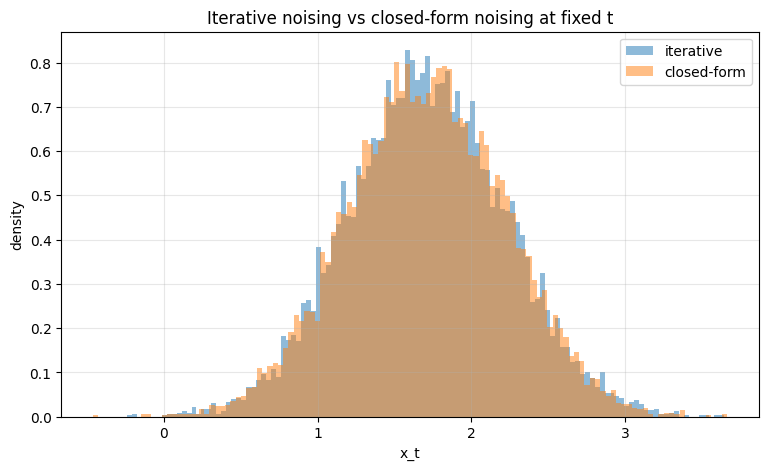

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(iterative_samples, bins=120, density=True, alpha=0.5, label='iterative')
ax.hist(closed_form_samples, bins=120, density=True, alpha=0.5, label='closed-form')
ax.set_title("Iterative noising vs closed-form noising at fixed t")
ax.set_xlabel("x_t")
ax.set_ylabel("density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The histograms should overlap closely, confirming the derivation of

$$
q(x_t \mid x_0)
=
\mathcal{N}\left(
x_t;
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right).
$$

## Posterior $q(x_{t-1} \mid x_t, x_0)$

This posterior is the next crucial quantity in DDPMs.

We will derive that

$$
q(x_{t-1} \mid x_t, x_0)
=
\mathcal{N}\left(
x_{t-1};
\tilde{\mu}_t(x_t, x_0),
\tilde{\beta}_t I
\right),
$$

with explicit formulas for $\tilde{\mu}_t$ and $\tilde{\beta}_t$.

### Step 1: Bayes structure

By the Markov property,

$$
q(x_{t-1} \mid x_t, x_0)
\propto
q(x_t \mid x_{t-1}, x_0)\,q(x_{t-1} \mid x_0).
$$

Since $x_t$ depends only on $x_{t-1}$,

$$
q(x_t \mid x_{t-1}, x_0) = q(x_t \mid x_{t-1}).
$$

So

$$
q(x_{t-1} \mid x_t, x_0)
\propto
q(x_t \mid x_{t-1})\,q(x_{t-1} \mid x_0).
$$

Now plug in the two Gaussian factors:

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}(x_t; \sqrt{\alpha_t}x_{t-1}, \beta_t I),
$$

$$
q(x_{t-1} \mid x_0)
=
\mathcal{N}(x_{t-1}; \sqrt{\bar{\alpha}_{t-1}}x_0, (1-\bar{\alpha}_{t-1})I).
$$

As a function of $x_{t-1}$, this is the product of two Gaussians, hence proportional to another Gaussian.

### Step 2: Expand the exponent

Ignoring constants independent of $x_{t-1}$,

$$
q(x_{t-1} \mid x_t, x_0)
\propto
\exp\left(
-\frac{1}{2\beta_t}\|x_t-\sqrt{\alpha_t}x_{t-1}\|^2
-\frac{1}{2(1-\bar{\alpha}_{t-1})}\|x_{t-1}-\sqrt{\bar{\alpha}_{t-1}}x_0\|^2
\right).
$$

Expand the first quadratic:

$$
\|x_t-\sqrt{\alpha_t}x_{t-1}\|^2
=
x_t^\top x_t
-2\sqrt{\alpha_t}x_t^\top x_{t-1}
+\alpha_t x_{t-1}^\top x_{t-1}.
$$

Expand the second quadratic:

$$
\|x_{t-1}-\sqrt{\bar{\alpha}_{t-1}}x_0\|^2
=
x_{t-1}^\top x_{t-1}
-2\sqrt{\bar{\alpha}_{t-1}}x_0^\top x_{t-1}
+\bar{\alpha}_{t-1}x_0^\top x_0.
$$

Collect only terms involving $x_{t-1}$. The exponent becomes

$$
-\frac{1}{2}
\left(
\frac{\alpha_t}{\beta_t}
+
\frac{1}{1-\bar{\alpha}_{t-1}}
\right)
x_{t-1}^\top x_{t-1}
+
\left(
\frac{\sqrt{\alpha_t}}{\beta_t}x_t
+
\frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0
\right)^\top x_{t-1}
+
\text{const}.
$$

This is the canonical form of a Gaussian.

### Step 3: Read off the precision and mean

Define

$$
A
=
\frac{\alpha_t}{\beta_t}
+
\frac{1}{1-\bar{\alpha}_{t-1}},
$$

and

$$
b
=
\frac{\sqrt{\alpha_t}}{\beta_t}x_t
+
\frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0.
$$

Then the Gaussian has variance

$$
\tilde{\beta}_t = A^{-1}
$$

and mean

$$
\tilde{\mu}_t = A^{-1}b.
$$

### Step 4: Simplify the variance

We have

$$
A = \frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar{\alpha}_{t-1}}.
$$

Put over a common denominator:

$$
A
=
\frac{\alpha_t(1-\bar{\alpha}_{t-1}) + \beta_t}{\beta_t(1-\bar{\alpha}_{t-1})}.
$$

Simplify the numerator:

$$
\alpha_t(1-\bar{\alpha}_{t-1}) + \beta_t
=
\alpha_t - \alpha_t\bar{\alpha}_{t-1} + \beta_t.
$$

Since $\alpha_t + \beta_t = 1$,

$$
=
1 - \alpha_t\bar{\alpha}_{t-1}
=
1 - \bar{\alpha}_t.
$$

Hence

$$
A = \frac{1-\bar{\alpha}_t}{\beta_t(1-\bar{\alpha}_{t-1})}.
$$

Therefore,

$$
\tilde{\beta}_t
=
A^{-1}
=
\frac{\beta_t(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}.
$$

### Step 5: Simplify the mean

We have

$$
\tilde{\mu}_t
=
\tilde{\beta}_t
\left(
\frac{\sqrt{\alpha_t}}{\beta_t}x_t
+
\frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0
\right).
$$

Substitute the simplified variance:

$$
\tilde{\mu}_t
=
\frac{\beta_t(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}
\left(
\frac{\sqrt{\alpha_t}}{\beta_t}x_t
+
\frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0
\right).
$$

Distribute:

$$
\tilde{\mu}_t
=
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t
+
\frac{\beta_t\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_t}x_0.
$$

So the posterior is

$$
q(x_{t-1} \mid x_t, x_0)
=
\mathcal{N}\left(
x_{t-1};
\tilde{\mu}_t(x_t,x_0),
\tilde{\beta}_t I
\right),
$$

where

$$
\tilde{\mu}_t(x_t,x_0)
=
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t
+
\frac{\beta_t\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_t}x_0,
$$

and

$$
\tilde{\beta}_t
=
\frac{\beta_t(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}.
$$

In [12]:
def posterior_mean_variance(x0, xt, t, betas, alphas, alpha_bars):
    beta_t = betas[t - 1]
    alpha_t = alphas[t - 1]
    alpha_bar_t = alpha_bars[t - 1]
    alpha_bar_prev = 1.0 if t == 1 else alpha_bars[t - 2]

    coef1 = np.sqrt(alpha_t) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
    coef2 = beta_t * np.sqrt(alpha_bar_prev) / (1.0 - alpha_bar_t)

    mean = coef1 * xt + coef2 * x0
    var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
    return mean, var

The next cell visualizes how the posterior variance behaves across time. This variance is important because it tells us how uncertain the reverse transition remains when both $x_t$ and $x_0$ are known.

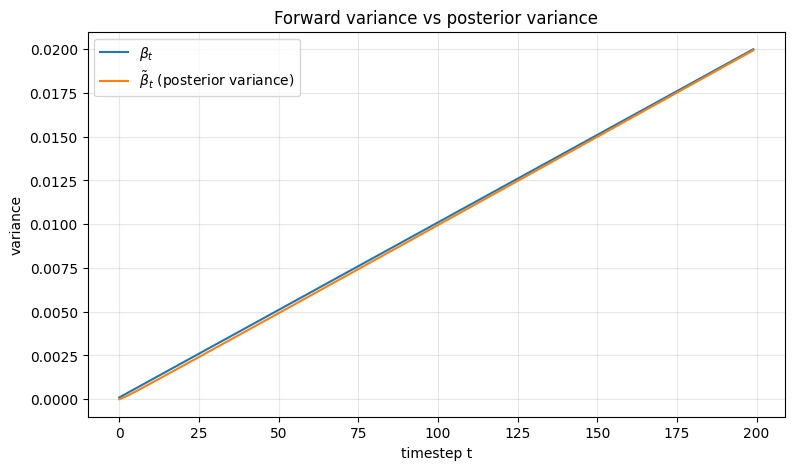

In [13]:
T_plot = 200
betas_plot = linear_beta_schedule(T_plot)
sched_plot = compute_diffusion_quantities(betas_plot)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sched_plot["betas"], label=r'$\beta_t$')
ax.plot(sched_plot["posterior_variance"], label=r'$\tilde{\beta}_t$ (posterior variance)')
ax.set_title("Forward variance vs posterior variance")
ax.set_xlabel("timestep t")
ax.set_ylabel("variance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

#### Interpretation

- $\beta_t$ is the variance injected by the forward process
- $\tilde{\beta}_t$ is the variance of the posterior $q(x_{t-1}\mid x_t, x_0)$

The posterior variance is generally smaller because conditioning on both $x_t$ and $x_0$ gives more information about $x_{t-1}$.

### Reverse process model

We now define the learned reverse generative process.

### Learned reverse chain

At generation time, we want to start from Gaussian noise and gradually denoise.

We define a simple prior at the terminal timestep:

$$
p(x_T) = \mathcal{N}(x_T; 0, I).
$$

Then define a learned reverse Markov chain

$$
p_\theta(x_{0:T})
=
p(x_T)\prod_{t=1}^T p_\theta(x_{t-1} \mid x_t).
$$

Each reverse conditional is parameterized as a Gaussian:

$$
p_\theta(x_{t-1} \mid x_t)
=
\mathcal{N}\left(
x_{t-1};
\mu_\theta(x_t,t),
\Sigma_\theta(x_t,t)
\right).
$$

Typically we model the mean and either fix the variance or learn it.

### Why Gaussian reverse transitions make sense

Although $q(x_{t-1}\mid x_t)$ is generally intractable, the conditional

$$
q(x_{t-1}\mid x_t, x_0)
$$

has an exact Gaussian form. That suggests a Gaussian family for the learned reverse transition.

Also, because each forward step is small, the reverse transition is locally close to Gaussian. This is one of the key reasons DDPMs are tractable.

## ELBO derivation

We now derive the variational training objective for DDPMs.

### Step 1: Marginal likelihood of the data

For one observed data point $x_0$, the model likelihood is

$$
p_\theta(x_0)
=
\int p_\theta(x_{0:T})\,dx_{1:T}.
$$

Introduce the forward process $q(x_{1:T}\mid x_0)$:

$$
\log p_\theta(x_0)
=
\log \int q(x_{1:T}\mid x_0)
\frac{p_\theta(x_{0:T})}{q(x_{1:T}\mid x_0)}
\,dx_{1:T}.
$$

This becomes

$$
\log p_\theta(x_0)
=
\log
\mathbb{E}_{q(x_{1:T}\mid x_0)}
\left[
\frac{p_\theta(x_{0:T})}{q(x_{1:T}\mid x_0)}
\right].
$$

Apply Jensen's inequality:

$$
\log p_\theta(x_0)
\ge
\mathbb{E}_{q(x_{1:T}\mid x_0)}
\left[
\log p_\theta(x_{0:T}) - \log q(x_{1:T}\mid x_0)
\right].
$$

Define the ELBO:

$$
\mathcal{L}_{\mathrm{ELBO}}
=
\mathbb{E}_{q(x_{1:T}\mid x_0)}
\left[
\log p_\theta(x_{0:T}) - \log q(x_{1:T}\mid x_0)
\right].
$$

Training minimizes the negative ELBO:

$$
L := -\mathcal{L}_{\mathrm{ELBO}}.
$$

### Step 2: Expand the factorization

The forward process factorizes as

$$
q(x_{1:T}\mid x_0)
=
\prod_{t=1}^T q(x_t \mid x_{t-1}),
$$

so

$$
\log q(x_{1:T}\mid x_0)
=
\sum_{t=1}^T \log q(x_t \mid x_{t-1}).
$$

The reverse model factorizes as

$$
p_\theta(x_{0:T})
=
p(x_T)\prod_{t=1}^T p_\theta(x_{t-1} \mid x_t),
$$

so

$$
\log p_\theta(x_{0:T})
=
\log p(x_T) + \sum_{t=1}^T \log p_\theta(x_{t-1}\mid x_t).
$$

Plugging into the ELBO gives

$$
\mathcal{L}_{\mathrm{ELBO}}
=
\mathbb{E}_q
\left[
\log p(x_T)
+
\sum_{t=1}^T \log p_\theta(x_{t-1}\mid x_t)
-
\sum_{t=1}^T \log q(x_t \mid x_{t-1})
\right].
$$

### Step 3: Rewrite the forward chain in posterior form

A key identity is

$$
q(x_{1:T}\mid x_0)
=
q(x_T\mid x_0)
\prod_{t=2}^T q(x_{t-1}\mid x_t, x_0).
$$

This comes from repeatedly applying Bayes' rule to the forward chain.

Using that identity, we can rewrite the ratio inside the ELBO as

$$
\frac{p_\theta(x_{0:T})}{q(x_{1:T}\mid x_0)}
=
\frac{p(x_T)}{q(x_T\mid x_0)}
\cdot
\prod_{t=2}^T
\frac{p_\theta(x_{t-1}\mid x_t)}{q(x_{t-1}\mid x_t, x_0)}
\cdot
p_\theta(x_0\mid x_1).
$$

Taking logs and expectations yields the standard decomposition.

### Step 4: ELBO decomposition across timesteps

The negative ELBO can be written as

$$
L
=
\mathbb{E}_q\left[
D_{\mathrm{KL}}(q(x_T\mid x_0)\|p(x_T))
+
\sum_{t=2}^T
D_{\mathrm{KL}}(q(x_{t-1}\mid x_t,x_0)\|p_\theta(x_{t-1}\mid x_t))
-
\log p_\theta(x_0 \mid x_1)
\right].
$$

This is one of the most important equations in DDPM theory.

It has three parts:

1. A prior-matching term at the terminal time
2. A sum of timestep-wise KL terms
3. A reconstruction term at the first step

### Interpretation of the ELBO terms

Let

$$
L_T = D_{\mathrm{KL}}(q(x_T\mid x_0)\|p(x_T)),
$$

$$
L_{t-1}
=
D_{\mathrm{KL}}(q(x_{t-1}\mid x_t,x_0)\|p_\theta(x_{t-1}\mid x_t)),
\qquad t=2,\dots,T,
$$

and

$$
L_0 = -\log p_\theta(x_0 \mid x_1).
$$

Then

$$
L = L_T + \sum_{t=2}^T L_{t-1} + L_0.
$$

- $L_T$ encourages the final noisy distribution to match a standard Gaussian
- $L_{t-1}$ trains the reverse model to match the true posterior transition
- $L_0$ is the final reconstruction-like term

In practice, the middle KL terms are the ones that lead to the familiar noise-prediction objective.

## Practical DDPM loss

We now derive the practical training objective used in DDPMs.

### Step 1: Choose a Gaussian reverse model with fixed variance

A common DDPM choice is

$$
p_\theta(x_{t-1}\mid x_t)
=
\mathcal{N}(x_{t-1}; \mu_\theta(x_t,t), \sigma_t^2 I),
$$

where $\sigma_t^2$ is fixed.

The true posterior is

$$
q(x_{t-1}\mid x_t,x_0)
=
\mathcal{N}(x_{t-1}; \tilde{\mu}_t(x_t,x_0), \tilde{\beta}_t I).
$$

Since both are Gaussian, the KL term is analytically tractable. If the variances are fixed, then up to constants and known weights, minimizing the KL is equivalent to matching the means:

$$
L_{t-1}
\propto
\mathbb{E}
\left[
\|\tilde{\mu}_t(x_t,x_0) - \mu_\theta(x_t,t)\|^2
\right].
$$

### Step 2: Express the posterior mean using the added noise $\epsilon$

Recall the closed-form noising identity

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I).
$$

Solve this for $x_0$:

$$
x_0
=
\frac{1}{\sqrt{\bar{\alpha}_t}}
\left(
x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon
\right).
$$

Now substitute into

$$
\tilde{\mu}_t(x_t,x_0)
=
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t
+
\frac{\beta_t\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_t}x_0.
$$

After algebraic simplification, one obtains

$$
\tilde{\mu}_t(x_t,x_0)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon
\right).
$$

This is the key bridge from posterior mean matching to noise prediction.

### Step 3: Parameterize the model via noise prediction

Let the neural network predict the noise:

$$
\epsilon_\theta(x_t,t) \approx \epsilon.
$$

Then define the reverse mean as

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)
\right).
$$

### Step 4: Show how the MSE on noise appears

We have

$$
\tilde{\mu}_t
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon
\right),
$$

and

$$
\mu_\theta
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta
\right).
$$

Subtract:

$$
\tilde{\mu}_t - \mu_\theta
=
-\frac{\beta_t}{\sqrt{\alpha_t}\sqrt{1-\bar{\alpha}_t}}
(\epsilon - \epsilon_\theta).
$$

Therefore,

$$
\|\tilde{\mu}_t - \mu_\theta\|^2
=
\frac{\beta_t^2}{\alpha_t(1-\bar{\alpha}_t)}
\|\epsilon - \epsilon_\theta\|^2.
$$

Hence, each KL term is proportional to a weighted MSE between the true noise and the predicted noise.

### Simplified DDPM objective

The original DDPM paper found that a simplified unweighted loss works very well in practice:

$$
L_{\text{simple}}
=
\mathbb{E}_{x_0,\epsilon,t}
\left[
\|\epsilon - \epsilon_\theta(x_t,t)\|^2
\right],
$$

where

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon.
$$

This is the standard training objective used in many diffusion implementations.



In [14]:
def recover_x0_from_epsilon_prediction(xt, eps_pred, alpha_bar_t):
    return (xt - np.sqrt(1.0 - alpha_bar_t) * eps_pred) / np.sqrt(alpha_bar_t)

def epsilon_from_x0(xt, x0, alpha_bar_t):
    return (xt - np.sqrt(alpha_bar_t) * x0) / np.sqrt(1.0 - alpha_bar_t)

The next code cell demonstrates the relationship between:

- clean sample $x_0$
- noisy sample $x_t$
- noise $\epsilon$

and shows that if we know $\epsilon$, we can recover $x_0$ exactly through

$$
x_0
=
\frac{x_t - \sqrt{1-\bar{\alpha}_t}\epsilon}{\sqrt{\bar{\alpha}_t}}.
$$

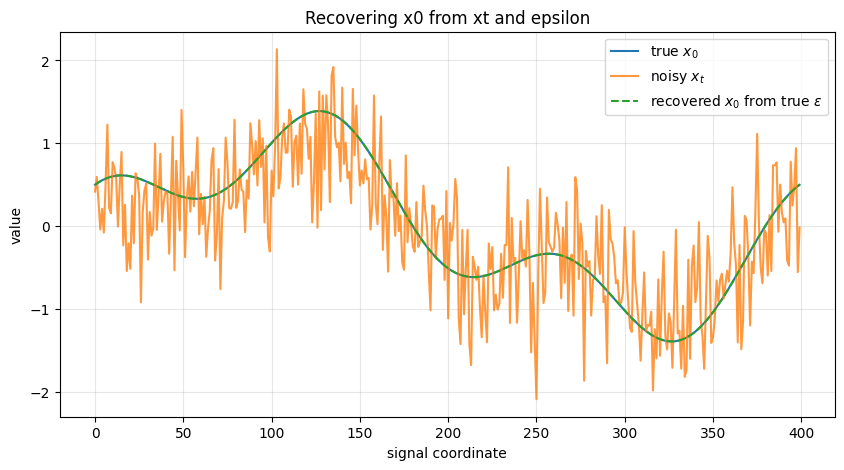

Max absolute reconstruction error: 2.220446049250313e-16


In [15]:
rng = np.random.default_rng(7)
n = 400
x = np.linspace(0, 1, n)
x0_demo = np.sin(2 * np.pi * x) + 0.5 * np.cos(6 * np.pi * x)

T_demo2 = 100
betas_demo2 = linear_beta_schedule(T_demo2)
sched_demo2 = compute_diffusion_quantities(betas_demo2)

t_demo = 60
alpha_bar_t = sched_demo2["alpha_bars"][t_demo - 1]
eps = rng.normal(size=x0_demo.shape)
xt_demo = np.sqrt(alpha_bar_t) * x0_demo + np.sqrt(1 - alpha_bar_t) * eps

x0_recovered = recover_x0_from_epsilon_prediction(xt_demo, eps, alpha_bar_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x0_demo, label=r'true $x_0$')
ax.plot(xt_demo, label=r'noisy $x_t$', alpha=0.8)
ax.plot(x0_recovered, '--', label=r'recovered $x_0$ from true $\epsilon$')
ax.set_title("Recovering x0 from xt and epsilon")
ax.set_xlabel("signal coordinate")
ax.set_ylabel("value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Max absolute reconstruction error:", np.max(np.abs(x0_demo - x0_recovered)))

# $\epsilon$-, $x_0$-, and $v$-parameterizations

The reverse model can be parameterized in multiple equivalent ways.

### 1. $\epsilon$-prediction

The network predicts the noise:

$$
\epsilon_\theta(x_t,t) \approx \epsilon.
$$

This is the standard DDPM parameterization.

Given $\epsilon_\theta$, the reverse mean is

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)
\right).
$$

### 2. $x_0$-prediction

Instead of predicting noise, the network may directly predict the clean sample:

$$
\hat{x}_{0,\theta}(x_t,t) \approx x_0.
$$

Then the predicted noise can be reconstructed by

$$
\hat{\epsilon}_\theta(x_t,t)
=
\frac{x_t - \sqrt{\bar{\alpha}_t}\hat{x}_{0,\theta}(x_t,t)}{\sqrt{1-\bar{\alpha}_t}}.
$$

Or equivalently, one may plug $\hat{x}_{0,\theta}$ directly into the posterior mean formula.

### 3. $v$-prediction

A popular modern alternative is to predict

$$
v := \sqrt{\bar{\alpha}_t}\,\epsilon - \sqrt{1-\bar{\alpha}_t}\,x_0.
$$

This is another linear reparameterization of the same information.

Given $(x_t, v)$, we can recover both $x_0$ and $\epsilon$:

$$
x_0 = \sqrt{\bar{\alpha}_t}\,x_t - \sqrt{1-\bar{\alpha}_t}\,v,
$$

$$
\epsilon = \sqrt{1-\bar{\alpha}_t}\,x_t + \sqrt{\bar{\alpha}_t}\,v.
$$

So the three parameterizations are mathematically equivalent up to invertible linear transformations.



In [16]:
def v_from_x0_epsilon(x0, eps, alpha_bar_t):
    return np.sqrt(alpha_bar_t) * eps - np.sqrt(1.0 - alpha_bar_t) * x0

def x0_from_xt_v(xt, v, alpha_bar_t):
    return np.sqrt(alpha_bar_t) * xt - np.sqrt(1.0 - alpha_bar_t) * v

def eps_from_xt_v(xt, v, alpha_bar_t):
    return np.sqrt(1.0 - alpha_bar_t) * xt + np.sqrt(alpha_bar_t) * v

The next cell numerically verifies the equivalence between the parameterizations.

In [17]:
rng = np.random.default_rng(21)
x0 = rng.normal(size=1000)
eps = rng.normal(size=1000)

alpha_bar_t = 0.37
xt = np.sqrt(alpha_bar_t) * x0 + np.sqrt(1 - alpha_bar_t) * eps
v = v_from_x0_epsilon(x0, eps, alpha_bar_t)

x0_rec = x0_from_xt_v(xt, v, alpha_bar_t)
eps_rec = eps_from_xt_v(xt, v, alpha_bar_t)

print("max |x0 - x0_rec| =", np.max(np.abs(x0 - x0_rec)))
print("max |eps - eps_rec| =", np.max(np.abs(eps - eps_rec)))

max |x0 - x0_rec| = 4.440892098500626e-16
max |eps - eps_rec| = 4.440892098500626e-16


## Training algorithm

We now state the DDPM training procedure explicitly.

### Training pipeline

For each training iteration:

1. Sample a clean data point $x_0 \sim p_{\text{data}}$.
2. Sample a timestep $t$ uniformly from $\{1,\dots,T\}$.
3. Sample noise $\epsilon \sim \mathcal{N}(0,I)$.
4. Construct the noisy sample

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon.
$$

5. Feed $(x_t, t)$ into the neural network.
6. Predict one of:
   - $\epsilon$
   - $x_0$
   - $v$
7. Compute the corresponding loss, most commonly

$$
\|\epsilon - \epsilon_\theta(x_t,t)\|^2.
$$

8. Update the network parameters by gradient descent.

Notice that training never needs to simulate the full forward chain step by step; direct noising via the closed form is enough.

## Sampling algorithm

We now state the generation procedure at inference time.

### Reverse ancestral sampling

At generation time we do not know $x_0$.

Instead:

1. Sample

$$
x_T \sim \mathcal{N}(0,I).
$$

2. For $t = T, T-1, \dots, 1$:
   - evaluate the neural network on $(x_t,t)$
   - construct the reverse mean $\mu_\theta(x_t,t)$
   - sample

$$
x_{t-1}
\sim
\mathcal{N}(\mu_\theta(x_t,t), \sigma_t^2 I)
$$

3. Return $x_0$

This is called **ancestral sampling** because we sample sequentially from the learned reverse Markov chain.

In [18]:
def ddpm_reverse_mean_from_eps(xt, eps_pred, t, betas, alphas, alpha_bars):
    beta_t = betas[t - 1]
    alpha_t = alphas[t - 1]
    alpha_bar_t = alpha_bars[t - 1]
    return (xt - (beta_t / np.sqrt(1.0 - alpha_bar_t)) * eps_pred) / np.sqrt(alpha_t)

The next demo does not use a trained neural network. Instead, it uses the **true** $\epsilon$ from the synthetic forward construction, so that we can see how the reverse mean behaves in an idealized setting.

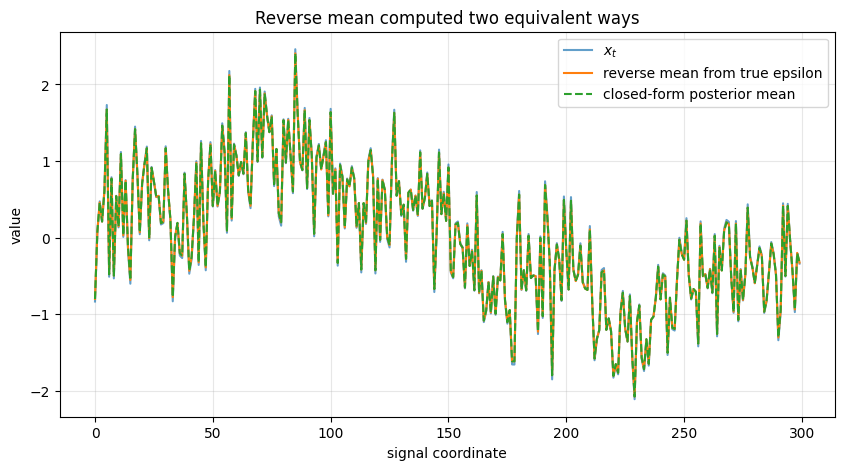

Max difference between two means: 4.440892098500626e-16
Posterior variance scalar: 0.012019444947095831


In [19]:
rng = np.random.default_rng(1234)

n = 300
grid = np.linspace(0, 2 * np.pi, n)
x0_clean = np.sin(grid) + 0.3 * np.sin(5 * grid)

T_toy = 80
betas_toy = linear_beta_schedule(T_toy)
sched_toy = compute_diffusion_quantities(betas_toy)

t = 50
alpha_bar_t = sched_toy["alpha_bars"][t - 1]
eps_true = rng.normal(size=x0_clean.shape)
xt = np.sqrt(alpha_bar_t) * x0_clean + np.sqrt(1 - alpha_bar_t) * eps_true

mu_reverse = ddpm_reverse_mean_from_eps(
    xt, eps_true, t, sched_toy["betas"], sched_toy["alphas"], sched_toy["alpha_bars"]
)

true_posterior_mean, true_posterior_var = posterior_mean_variance(
    x0_clean, xt, t, sched_toy["betas"], sched_toy["alphas"], sched_toy["alpha_bars"]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xt, label=r'$x_t$', alpha=0.7)
ax.plot(mu_reverse, label='reverse mean from true epsilon')
ax.plot(true_posterior_mean, '--', label='closed-form posterior mean')
ax.set_title("Reverse mean computed two equivalent ways")
ax.set_xlabel("signal coordinate")
ax.set_ylabel("value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Max difference between two means:", np.max(np.abs(mu_reverse - true_posterior_mean)))
print("Posterior variance scalar:", true_posterior_var)

This verifies the equivalence between:

- the posterior mean formula derived from Gaussian algebra
- the mean formula expressed through $\epsilon$-prediction

That equivalence is the mathematical reason the DDPM training objective can be written as noise prediction.

## Implementation notes

We now connect the theory to actual implementation details.

### What is actually sampled during training?

For each minibatch item, we sample:

- a clean data point $x_0$
- a timestep $t$
- Gaussian noise $\epsilon$

Then we construct

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon.
$$

This pair $(x_t, t)$ becomes the network input, and $\epsilon$ becomes the supervision target for standard DDPM training.

### Why the network needs the timestep

The amount of noise in $x_t$ depends strongly on $t$.

The same input pattern could correspond to very different denoising problems depending on whether the sample is only slightly noisy or almost pure noise.

So the network must know the timestep. In practice, $t$ is embedded using sinusoidal or learned embeddings and injected into the network.

### Why direct noising from $x_0$ is enough during training

The forward process is defined as a Markov chain, but the closed form

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
$$

gives the exact marginal at time $t$.

So training can skip explicit simulation of all intermediate forward states. This is mathematically exact, not an approximation.

### Why the final prior is standard Gaussian

If $T$ is large enough and the schedule is chosen well, then repeated noising drives samples toward something close to

$$
\mathcal{N}(0,I).
$$

This justifies choosing

$$
p(x_T) = \mathcal{N}(0,I)
$$

as the start of the reverse generative process.

### Relationship to score matching

For

$$
q(x_t \mid x_0)
=
\mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I),
$$

the score with respect to $x_t$ is

$$
\nabla_{x_t}\log q(x_t \mid x_0)
=
-\frac{x_t - \sqrt{\bar{\alpha}_t}x_0}{1-\bar{\alpha}_t}.
$$

Since

$$
x_t - \sqrt{\bar{\alpha}_t}x_0
=
\sqrt{1-\bar{\alpha}_t}\epsilon,
$$

we get

$$
\nabla_{x_t}\log q(x_t \mid x_0)
=
-\frac{\epsilon}{\sqrt{1-\bar{\alpha}_t}}.
$$

So predicting $\epsilon$ is equivalent, up to a known scale, to predicting the score of the noisy conditional distribution.

### Brief intuition for classifier-free guidance

In conditional diffusion, the model may be trained both:

- conditionally: $\epsilon_\theta(x_t,t,c)$
- unconditionally: $\epsilon_\theta(x_t,t,\varnothing)$

Then at sampling time we use

$$
\epsilon_{\text{guided}}
=
\epsilon_\theta(x_t,t,\varnothing)
+
w\left(
\epsilon_\theta(x_t,t,c) - \epsilon_\theta(x_t,t,\varnothing)
\right),
$$

where $w$ is the guidance scale.

Interpretation:

- the unconditional prediction gives the baseline denoising direction
- the conditional prediction adds information specific to the condition
- amplifying the difference strengthens adherence to the condition

### Brief mention of DDIM

DDPM uses stochastic ancestral sampling.

DDIM modifies the sampling process to allow deterministic or partially deterministic trajectories while using the same training objective.

So:

- **DDPM**: stochastic reverse chain
- **DDIM**: alternative non-Markovian sampling procedure derived from the same learned model

## Common confusions and clarifications

### 1. Why is $q(x_{t-1}\mid x_t,x_0)$ tractable but $q(x_{t-1}\mid x_t)$ intractable?

Because conditioning on $x_0$ makes the problem Gaussian and linear.

Without conditioning on $x_0$, one would need to marginalize over the unknown data posterior:

$$
q(x_{t-1}\mid x_t)
=
\int q(x_{t-1}\mid x_t,x_0)\,q(x_0\mid x_t)\,dx_0,
$$

and $q(x_0\mid x_t)$ depends on the true data distribution, which is not analytically known.

### 2. Why predict $\epsilon$ instead of directly predicting $x_{t-1}$?

Because:

- the target $\epsilon$ has a simple standard Gaussian distribution
- the posterior mean can be expressed directly in terms of $\epsilon$
- the training objective becomes a simple regression problem
- it exposes the connection to score matching

### 3. Does direct sampling of $x_t$ break the Markov interpretation?

No.

The forward chain still exists mathematically. The direct formula

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon
$$

is simply the exact closed-form marginal of that chain.

### 4. Is DDPM maximizing likelihood exactly?

Not exactly. It optimizes an ELBO, which is a lower bound on the data log-likelihood.

Then the practical simplified objective is an especially convenient surrogate of that ELBO.

### 5. Where does denoising actually happen?

At every reverse step.

The model sees a noisy sample $x_t$, predicts the noise or the clean component, constructs a reverse mean, and moves to a slightly less noisy sample $x_{t-1}$.

Generation is gradual, not one-shot.

### 6. Why are Gaussian identities so central?

Because they give exact formulas for:

- the forward marginal $q(x_t\mid x_0)$
- the posterior $q(x_{t-1}\mid x_t,x_0)$
- the Gaussian KLs inside the ELBO

Without these identities, the core DDPM derivation would not collapse into such a clean training objective.

## Summary

### Core equations in one place

#### Forward step

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}(x_t; \sqrt{\alpha_t}x_{t-1}, \beta_t I),
\qquad \alpha_t = 1-\beta_t.
$$

#### Forward marginal

$$
q(x_t \mid x_0)
=
\mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I),
\qquad
\bar{\alpha}_t = \prod_{s=1}^t \alpha_s.
$$

Equivalent sampling form:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I).
$$

#### Posterior

$$
q(x_{t-1}\mid x_t,x_0)
=
\mathcal{N}(x_{t-1}; \tilde{\mu}_t(x_t,x_0), \tilde{\beta}_t I),
$$

with

$$
\tilde{\mu}_t(x_t,x_0)
=
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t
+
\frac{\beta_t\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_t}x_0,
$$

$$
\tilde{\beta}_t
=
\frac{\beta_t(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}.
$$

#### Reverse model

$$
p_\theta(x_{t-1}\mid x_t)
=
\mathcal{N}(x_{t-1}; \mu_\theta(x_t,t), \sigma_t^2 I).
$$

#### Noise-prediction mean parameterization

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)
\right).
$$

#### Simplified training loss

$$
L_{\text{simple}}
=
\mathbb{E}_{x_0,\epsilon,t}
\left[
\|\epsilon - \epsilon_\theta(x_t,t)\|^2
\right].
$$

#### Sampling

Start with

$$
x_T \sim \mathcal{N}(0,I),
$$

then run the learned reverse chain:

$$
x_{t-1}\sim \mathcal{N}(\mu_\theta(x_t,t), \sigma_t^2 I).
$$

### Final conceptual takeaway

A DDPM is a deep latent-variable generative model built from two coupled processes:

1. A fixed Gaussian forward process that gradually corrupts data into noise.
2. A learned reverse process that gradually reconstructs data from noise.

The elegance of DDPMs comes from the fact that Gaussian algebra makes:

- the forward marginal tractable,
- the posterior tractable,
- the ELBO decomposable,
- and the practical loss reducible to a denoising regression objective.

That is the mathematical core of DDPMs.

## DDPM training from scratch

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Reproducibility
# ============================================================
def seed_everything(seed: int = 42):
    np.random.seed(seed)

seed_everything(42)
print("Using pure NumPy / Python implementation")


# ============================================================
# 2. Dataset: pinwheel
# ============================================================
def make_pinwheel(n_samples: int = 20000,
                  radial_std: float = 0.3,
                  tangential_std: float = 0.1,
                  num_classes: int = 5,
                  rate: float = 0.25,
                  scale: float = 2.0):
    """
    Returns:
        x: np.ndarray of shape [n_samples, 2]
        y: np.ndarray of shape [n_samples]
    """
    num_per_class = n_samples // num_classes
    rads = np.linspace(0, 2 * np.pi, num_classes, endpoint=False)

    features = np.random.randn(num_classes * num_per_class, 2)
    features[:, 0] *= radial_std
    features[:, 1] *= tangential_std
    features[:, 0] += 1.0

    labels = np.repeat(np.arange(num_classes), num_per_class)

    angles = rads[labels] + rate * np.exp(features[:, 0])
    rotations = np.stack(
        [np.cos(angles), -np.sin(angles), np.sin(angles), np.cos(angles)],
        axis=1
    ).reshape(-1, 2, 2)

    data = np.einsum("ti,tij->tj", features, rotations)
    data *= scale

    perm = np.random.permutation(len(data))
    return data[perm].astype(np.float64), labels[perm].astype(np.int64)


# ============================================================
# 3. Diffusion schedule
# ============================================================
def linear_beta_schedule(T: int, beta_start: float = 1e-4, beta_end: float = 2e-2):
    return np.linspace(beta_start, beta_end, T, dtype=np.float64)

def make_ddpm_schedule(T: int):
    betas = linear_beta_schedule(T)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas, axis=0)
    alpha_bars_prev = np.concatenate([np.array([1.0], dtype=np.float64), alpha_bars[:-1]], axis=0)

    sqrt_alphas = np.sqrt(alphas)
    sqrt_alpha_bars = np.sqrt(alpha_bars)
    sqrt_one_minus_alpha_bars = np.sqrt(1.0 - alpha_bars)

    posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

    return {
        "T": T,
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
        "alpha_bars_prev": alpha_bars_prev,
        "sqrt_alphas": sqrt_alphas,
        "sqrt_alpha_bars": sqrt_alpha_bars,
        "sqrt_one_minus_alpha_bars": sqrt_one_minus_alpha_bars,
        "posterior_variance": posterior_variance,
    }


# ============================================================
# 4. Time embedding
# ============================================================
def sinusoidal_time_embedding(t: np.ndarray, dim: int):
    """
    t: [B] integer timesteps
    returns: [B, dim]
    """
    t = np.asarray(t, dtype=np.float64)
    half_dim = dim // 2
    emb_scale = math.log(10000) / max(half_dim - 1, 1)
    freqs = np.exp(np.arange(half_dim, dtype=np.float64) * -emb_scale)
    emb = t[:, None] * freqs[None, :]
    emb = np.concatenate([np.sin(emb), np.cos(emb)], axis=1)
    if dim % 2 == 1:
        emb = np.pad(emb, ((0, 0), (0, 1)))
    return emb


# ============================================================
# 5. Tiny MLP denoiser for 2D DDPM (pure NumPy)
# ============================================================
def silu(x):
    sig = 1.0 / (1.0 + np.exp(-x))
    return x * sig

def silu_grad(x):
    sig = 1.0 / (1.0 + np.exp(-x))
    return sig + x * sig * (1.0 - sig)

class MLPDenoiser:
    def __init__(self, x_dim: int = 2, time_dim: int = 64, hidden_dim: int = 128, lr: float = 1e-3):
        self.x_dim = x_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.lr = lr

        in_dim = x_dim + time_dim
        h = hidden_dim
        out_dim = x_dim

        rng = np.random.default_rng(42)

        # Xavier-like init
        self.params = {
            "W1": rng.normal(scale=np.sqrt(2.0 / (in_dim + h)), size=(in_dim, h)),
            "b1": np.zeros(h, dtype=np.float64),
            "W2": rng.normal(scale=np.sqrt(2.0 / (h + h)), size=(h, h)),
            "b2": np.zeros(h, dtype=np.float64),
            "W3": rng.normal(scale=np.sqrt(2.0 / (h + h)), size=(h, h)),
            "b3": np.zeros(h, dtype=np.float64),
            "W4": rng.normal(scale=np.sqrt(2.0 / (h + out_dim)), size=(h, out_dim)),
            "b4": np.zeros(out_dim, dtype=np.float64),
        }

        self.grads = {k: np.zeros_like(v) for k, v in self.params.items()}

        # Adam state
        self.m = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.eps = 1e-8
        self.step_count = 0

    def _forward_internal(self, x_t: np.ndarray, t: np.ndarray):
        t_emb = sinusoidal_time_embedding(t, self.time_dim)
        h0 = np.concatenate([x_t, t_emb], axis=1)

        z1 = h0 @ self.params["W1"] + self.params["b1"]
        h1 = silu(z1)

        z2 = h1 @ self.params["W2"] + self.params["b2"]
        h2 = silu(z2)

        z3 = h2 @ self.params["W3"] + self.params["b3"]
        h3 = silu(z3)

        out = h3 @ self.params["W4"] + self.params["b4"]

        cache = {
            "h0": h0,
            "z1": z1, "h1": h1,
            "z2": z2, "h2": h2,
            "z3": z3, "h3": h3,
            "out": out
        }
        return out, cache

    def __call__(self, x_t: np.ndarray, t: np.ndarray):
        out, _ = self._forward_internal(x_t, t)
        return out

    def train_step(self, x_t: np.ndarray, t: np.ndarray, noise_target: np.ndarray):
        """
        Minimizes MSE(noise_pred, noise_target)
        """
        B = x_t.shape[0]
        pred, cache = self._forward_internal(x_t, t)

        diff = pred - noise_target
        loss = np.mean(diff ** 2)

        # dL/dout for mean over all entries
        dout = (2.0 / diff.size) * diff

        # layer 4
        self.grads["W4"] = cache["h3"].T @ dout
        self.grads["b4"] = np.sum(dout, axis=0)

        dh3 = dout @ self.params["W4"].T
        dz3 = dh3 * silu_grad(cache["z3"])

        # layer 3
        self.grads["W3"] = cache["h2"].T @ dz3
        self.grads["b3"] = np.sum(dz3, axis=0)

        dh2 = dz3 @ self.params["W3"].T
        dz2 = dh2 * silu_grad(cache["z2"])

        # layer 2
        self.grads["W2"] = cache["h1"].T @ dz2
        self.grads["b2"] = np.sum(dz2, axis=0)

        dh1 = dz2 @ self.params["W2"].T
        dz1 = dh1 * silu_grad(cache["z1"])

        # layer 1
        self.grads["W1"] = cache["h0"].T @ dz1
        self.grads["b1"] = np.sum(dz1, axis=0)

        self._adam_step()
        return float(loss)

    def _adam_step(self):
        self.step_count += 1
        t = self.step_count

        for k in self.params.keys():
            g = self.grads[k]
            self.m[k] = self.beta1 * self.m[k] + (1.0 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1.0 - self.beta2) * (g * g)

            m_hat = self.m[k] / (1.0 - self.beta1 ** t)
            v_hat = self.v[k] / (1.0 - self.beta2 ** t)

            self.params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


# ============================================================
# 6. Core DDPM functions (NumPy)
# ============================================================
def extract(a: np.ndarray, t: np.ndarray, x_shape):
    """
    a: [T]
    t: [B] with values in [0, T-1]
    returns: [B, 1, ..., 1] broadcastable to x_shape
    """
    out = a[t]
    return out.reshape(t.shape[0], *([1] * (len(x_shape) - 1)))

def q_sample(x0: np.ndarray, t: np.ndarray, schedule: dict, noise: np.ndarray = None):
    if noise is None:
        noise = np.random.randn(*x0.shape)
    sqrt_ab = extract(schedule["sqrt_alpha_bars"], t, x0.shape)
    sqrt_1mab = extract(schedule["sqrt_one_minus_alpha_bars"], t, x0.shape)
    x_t = sqrt_ab * x0 + sqrt_1mab * noise
    return x_t, noise

def predict_x0_from_eps(x_t: np.ndarray, t: np.ndarray, eps_pred: np.ndarray, schedule: dict):
    sqrt_ab = extract(schedule["sqrt_alpha_bars"], t, x_t.shape)
    sqrt_1mab = extract(schedule["sqrt_one_minus_alpha_bars"], t, x_t.shape)
    x0_pred = (x_t - sqrt_1mab * eps_pred) / sqrt_ab
    return x0_pred

def p_sample(model: MLPDenoiser, x_t: np.ndarray, t: np.ndarray, schedule: dict):
    """
    One reverse sampling step.
    t is [B] integer array in [0, T-1]
    """
    betas = schedule["betas"]
    alphas = schedule["alphas"]
    alpha_bars = schedule["alpha_bars"]
    posterior_variance = schedule["posterior_variance"]

    beta_t = extract(betas, t, x_t.shape)
    alpha_t = extract(alphas, t, x_t.shape)
    alpha_bar_t = extract(alpha_bars, t, x_t.shape)

    eps_pred = model(x_t, t)

    mean = (1.0 / np.sqrt(alpha_t)) * (
        x_t - (beta_t / np.sqrt(1.0 - alpha_bar_t)) * eps_pred
    )

    var = extract(posterior_variance, t, x_t.shape)

    noise = np.random.randn(*x_t.shape)
    nonzero_mask = (t > 0).astype(np.float64).reshape(x_t.shape[0], *([1] * (len(x_t.shape) - 1)))
    x_prev = mean + nonzero_mask * np.sqrt(np.clip(var, 1e-20, None)) * noise
    return x_prev

def sample_reverse_trajectory(model: MLPDenoiser, n_samples: int, schedule: dict, store_every: int = 5):
    T = schedule["T"]
    x = np.random.randn(n_samples, 2)

    frames = [x.copy()]
    for step in reversed(range(T)):
        t = np.full((n_samples,), step, dtype=np.int64)
        x = p_sample(model, x, t, schedule)
        if (step % store_every == 0) or (step == 0):
            frames.append(x.copy())
    return frames

def sample_forward_trajectory(x0: np.ndarray, schedule: dict, store_every: int = 5):
    betas = schedule["betas"]
    alphas = schedule["alphas"]
    T = schedule["T"]

    x = x0.copy()
    frames = [x.copy()]
    for step in range(T):
        noise = np.random.randn(*x.shape)
        x = np.sqrt(alphas[step]) * x + np.sqrt(betas[step]) * noise
        if ((step + 1) % store_every == 0) or (step == T - 1):
            frames.append(x.copy())
    return frames

def sample_final(model: MLPDenoiser, n_samples: int, schedule: dict):
    x = np.random.randn(n_samples, 2)
    T = schedule["T"]
    for step in reversed(range(T)):
        t = np.full((n_samples,), step, dtype=np.int64)
        x = p_sample(model, x, t, schedule)
    return x


# ============================================================
# 7. Plot utilities
# ============================================================
def plot_dataset(x: np.ndarray, y: np.ndarray = None, title: str = "Dataset"):
    plt.figure(figsize=(6, 6))
    if y is None:
        plt.scatter(x[:, 0], x[:, 1], s=3, alpha=0.7)
    else:
        plt.scatter(x[:, 0], x[:, 1], c=y, s=3, alpha=0.7, cmap="hsv")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()

def plot_losses(losses, smooth_window: int = 20):
    plt.figure(figsize=(8, 4))
    plt.plot(losses, alpha=0.35, label="batch loss")
    if len(losses) >= smooth_window:
        kernel = np.ones(smooth_window) / smooth_window
        smooth = np.convolve(losses, kernel, mode="valid")
        plt.plot(
            np.arange(smooth_window - 1, len(losses)),
            smooth,
            linewidth=2,
            label=f"moving avg ({smooth_window})"
        )
    plt.title("Training loss")
    plt.xlabel("iteration")
    plt.ylabel("MSE on epsilon")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()


# ============================================================
# 8. Mini-batch iterator
# ============================================================
def iterate_minibatches(x: np.ndarray, batch_size: int, shuffle: bool = True, drop_last: bool = True):
    n = len(x)
    idx = np.arange(n)
    if shuffle:
        np.random.shuffle(idx)

    if drop_last:
        
        last = n - (n % batch_size)
        idx = idx[:last]

    for start in range(0, len(idx), batch_size):
        batch_idx = idx[start:start + batch_size]
        if len(batch_idx) < batch_size and drop_last:
            continue
        yield x[batch_idx]

Using pure NumPy / Python implementation


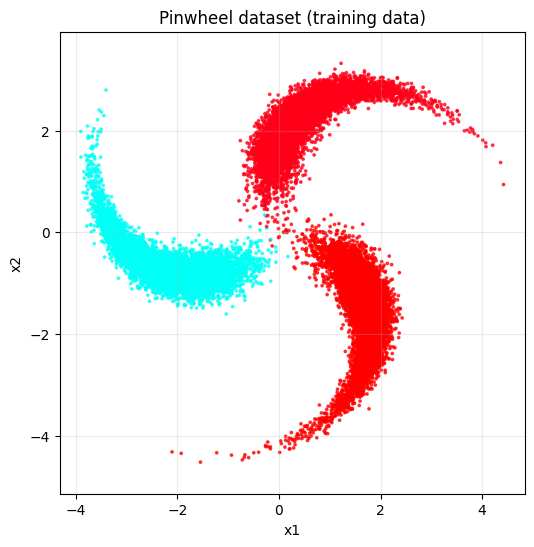

Epoch 01/25 | avg loss = 0.829044
Epoch 02/25 | avg loss = 0.734988
Epoch 03/25 | avg loss = 0.722766
Epoch 04/25 | avg loss = 0.703437
Epoch 05/25 | avg loss = 0.680532
Epoch 06/25 | avg loss = 0.652576
Epoch 07/25 | avg loss = 0.621939
Epoch 08/25 | avg loss = 0.592040
Epoch 09/25 | avg loss = 0.571747
Epoch 10/25 | avg loss = 0.564304
Epoch 11/25 | avg loss = 0.565166
Epoch 12/25 | avg loss = 0.553008
Epoch 13/25 | avg loss = 0.551253
Epoch 14/25 | avg loss = 0.548118
Epoch 15/25 | avg loss = 0.538855
Epoch 16/25 | avg loss = 0.546232
Epoch 17/25 | avg loss = 0.539357
Epoch 18/25 | avg loss = 0.544770
Epoch 19/25 | avg loss = 0.544413
Epoch 20/25 | avg loss = 0.540531
Epoch 21/25 | avg loss = 0.544180
Epoch 22/25 | avg loss = 0.540002
Epoch 23/25 | avg loss = 0.541568
Epoch 24/25 | avg loss = 0.536431
Epoch 25/25 | avg loss = 0.538234


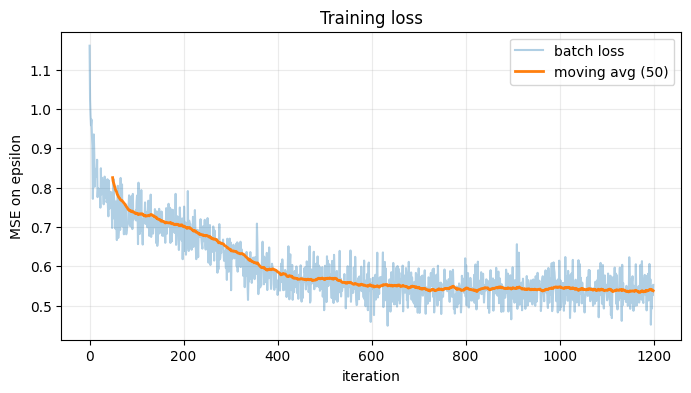

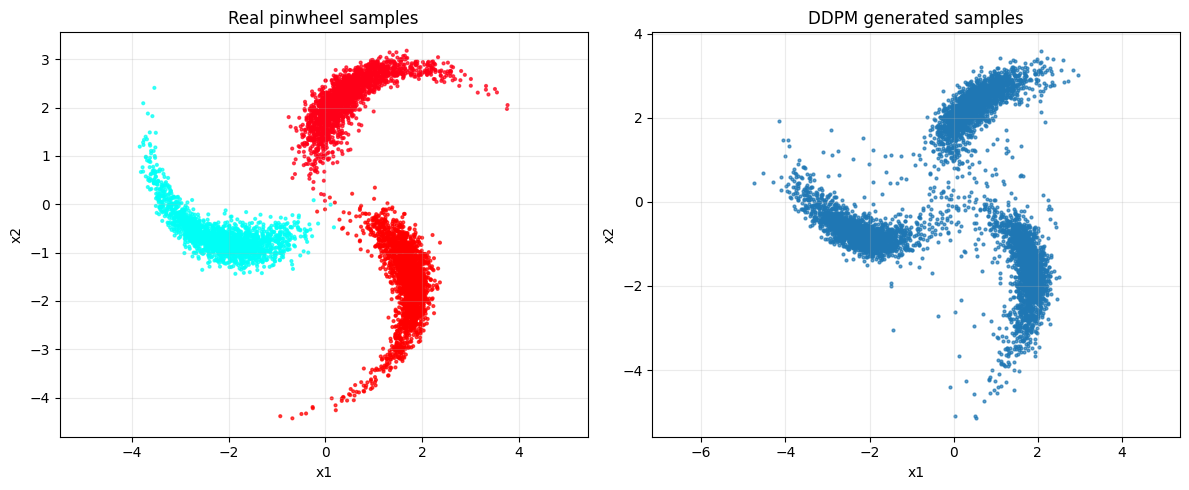

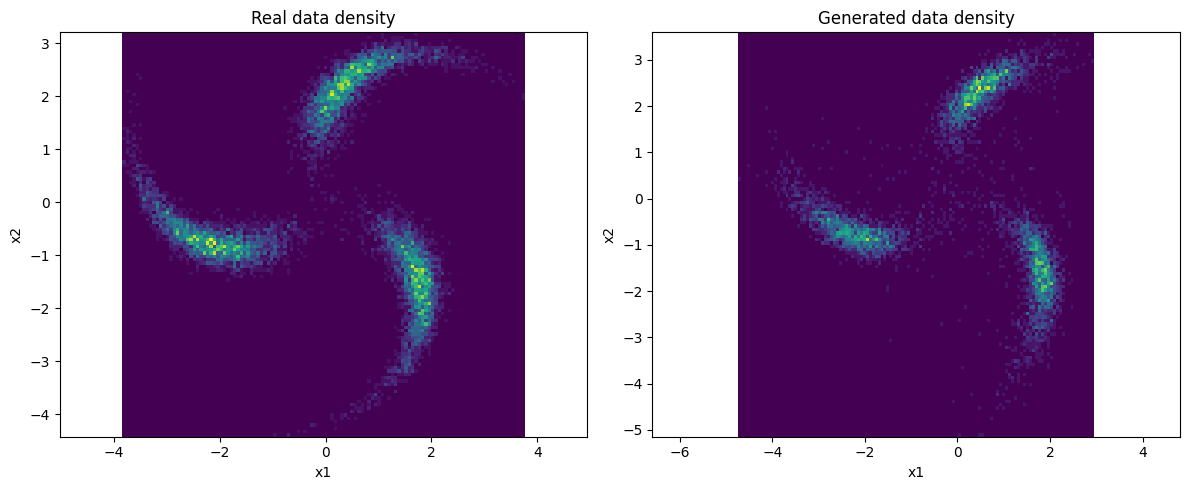

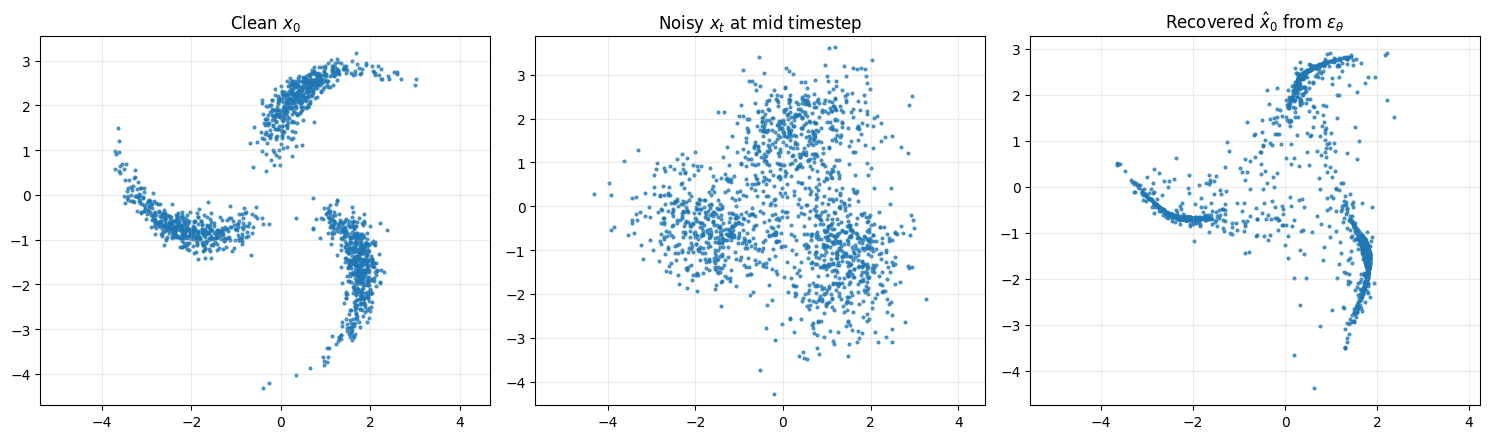

In [8]:
# ============================================================
# Minimal DDPM training on pinwheel (pure NumPy / Python)
# ============================================================

# ------------------------
# 1. Create colorful data
# ------------------------
x_np, y_np = make_pinwheel(
    n_samples=25000,
    radial_std=0.28,
    tangential_std=0.10,
    num_classes=3,
    rate=0.25,
    scale=2.3,
)

plot_dataset(x_np, y_np, title="Pinwheel dataset (training data)")

# ------------------------
# 2. DDPM config
# ------------------------
T = 200
schedule = make_ddpm_schedule(T)

model = MLPDenoiser(x_dim=2, time_dim=64, hidden_dim=128, lr=1e-3)

# ------------------------
# 3. Train
# ------------------------
epochs = 25
batch_size = 512
losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    n_batches = 0

    for x0 in iterate_minibatches(x_np, batch_size=batch_size, shuffle=True, drop_last=True):
        bsz = x0.shape[0]
        t = np.random.randint(0, T, size=(bsz,), dtype=np.int64)

        x_t, noise = q_sample(x0, t, schedule)
        loss = model.train_step(x_t, t, noise)

        losses.append(loss)
        epoch_loss += loss
        n_batches += 1

    avg_epoch_loss = epoch_loss / max(n_batches, 1)
    print(f"Epoch {epoch+1:02d}/{epochs} | avg loss = {avg_epoch_loss:.6f}")

# ------------------------
# 4. Plot training loss
# ------------------------
plot_losses(losses, smooth_window=50)

# ------------------------
# 5. Sample from trained model
# ------------------------
samples = sample_final(model, n_samples=6000, schedule=schedule)

# ------------------------
# 6. Compare data vs generated
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x_np[:6000, 0], x_np[:6000, 1], c=y_np[:6000], s=4, alpha=0.7, cmap="hsv")
axes[0].set_title("Real pinwheel samples")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.7)
axes[1].set_title("DDPM generated samples")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------
# 7. Nice density-ish comparison using hist2d
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist2d(x_np[:10000, 0], x_np[:10000, 1], bins=120)
axes[0].set_title("Real data density")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].axis("equal")

axes[1].hist2d(samples[:, 0], samples[:, 1], bins=120)
axes[1].set_title("Generated data density")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].axis("equal")

plt.tight_layout()
plt.show()

# ------------------------
# 8. Show denoising relation on a random batch
# ------------------------
x0_vis = x_np[:1500]
t_vis = np.full((x0_vis.shape[0],), T // 2, dtype=np.int64)

x_t_vis, eps_true = q_sample(x0_vis, t_vis, schedule)
eps_pred = model(x_t_vis, t_vis)
x0_pred = predict_x0_from_eps(x_t_vis, t_vis, eps_pred, schedule)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(x0_vis[:, 0], x0_vis[:, 1], s=4, alpha=0.7)
axes[0].set_title(r"Clean $x_0$")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(x_t_vis[:, 0], x_t_vis[:, 1], s=4, alpha=0.7)
axes[1].set_title(r"Noisy $x_t$ at mid timestep")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

axes[2].scatter(x0_pred[:, 0], x0_pred[:, 1], s=4, alpha=0.7)
axes[2].set_title(r"Recovered $\hat{x}_0$ from $\epsilon_\theta$")
axes[2].axis("equal")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()